# 03 — Baseline Models

## Objectives
1. Load the color-feature matrix from `02_feature_extraction.ipynb`
2. Train traditional ML baselines (Ridge, SVR, XGBoost) on hand-crafted features
3. Evaluate with MAE, RMSE, and R² via cross-validation and holdout test split
4. Perform feature importance analysis
5. Establish performance floor before deep learning (ViT)

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TEST_SIZE = 0.2

print("Dependencies loaded.")

Dependencies loaded.


## 1. Load Feature Matrix

In [2]:
FEATURES_CSV = "../data/processed/color_features.csv"

df = pd.read_csv(FEATURES_CSV)

# Separate features from metadata
meta_cols = ["PATIENT_ID", "hb_gdL", "HB_LEVEL_GperL"]
feature_cols = [c for c in df.columns if c not in meta_cols]

X = df[feature_cols].values
y = df["hb_gdL"].values  # target in g/dL

print(f"Samples:  {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Target range: [{y.min():.1f}, {y.max():.1f}] g/dL")
print(f"\nFeature columns:\n  {feature_cols}")

Samples:  250
Features: 51
Target range: [4.4, 16.9] g/dL

Feature columns:
  ['nail_rgb_R_mean', 'nail_rgb_R_std', 'nail_rgb_R_median', 'nail_rgb_G_mean', 'nail_rgb_G_std', 'nail_rgb_G_median', 'nail_rgb_B_mean', 'nail_rgb_B_std', 'nail_rgb_B_median', 'nail_lab_L_mean', 'nail_lab_L_std', 'nail_lab_A_mean', 'nail_lab_A_std', 'nail_lab_B_lab_mean', 'nail_lab_B_lab_std', 'nail_hsv_H_mean', 'nail_hsv_H_std', 'nail_hsv_S_mean', 'nail_hsv_S_std', 'nail_hsv_V_mean', 'nail_hsv_V_std', 'skin_rgb_R_mean', 'skin_rgb_R_std', 'skin_rgb_R_median', 'skin_rgb_G_mean', 'skin_rgb_G_std', 'skin_rgb_G_median', 'skin_rgb_B_mean', 'skin_rgb_B_std', 'skin_rgb_B_median', 'skin_lab_L_mean', 'skin_lab_L_std', 'skin_lab_A_mean', 'skin_lab_A_std', 'skin_lab_B_lab_mean', 'skin_lab_B_lab_std', 'skin_hsv_H_mean', 'skin_hsv_H_std', 'skin_hsv_S_mean', 'skin_hsv_S_std', 'skin_hsv_V_mean', 'skin_hsv_V_std', 'contrast_rgb_R_mean', 'contrast_rgb_G_mean', 'contrast_rgb_B_mean', 'contrast_lab_L_mean', 'contrast_lab_A_mean'

## 2. Train / Test Split & Scaling

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape[0]} samples")
print(f"Test:  {X_test_s.shape[0]} samples")

Train: 200 samples
Test:  50 samples


## 3. Train & Evaluate Baselines

In [4]:
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "SVR (RBF)": SVR(kernel="rbf", C=10.0, epsilon=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=8, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE
    ),
}

results = []
trained_models = {}

for name, model in models.items():
    # Fit
    model.fit(X_train_s, y_train)
    trained_models[name] = model
    
    # Predict
    y_pred = model.predict(X_test_s)
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # 5-fold CV MAE
    cv_scores = cross_val_score(model, X_train_s, y_train, cv=5, scoring="neg_mean_absolute_error")
    cv_mae = -cv_scores.mean()
    
    results.append({
        "Model": name,
        "Test MAE (g/dL)": round(mae, 3),
        "Test RMSE (g/dL)": round(rmse, 3),
        "Test R²": round(r2, 3),
        "CV MAE (g/dL)": round(cv_mae, 3),
    })

results_df = pd.DataFrame(results).sort_values("Test MAE (g/dL)")
display(results_df)

# Highlight best
best = results_df.iloc[0]
print(f"\n✦ Best model: {best['Model']}")
print(f"  MAE = {best['Test MAE (g/dL)']:.3f} g/dL, R² = {best['Test R²']:.3f}")

,Model,Test MAE (g/dL),Test RMSE (g/dL),Test R²,CV MAE (g/dL)
0,Ridge Regression,1.575,2.073,0.384,1.635
3,Random Forest,1.610,2.199,0.307,1.602
4,Gradient Boosting,1.649,2.228,0.288,1.751
1,Lasso Regression,1.692,2.172,0.324,1.578
2,SVR (RBF),1.774,2.317,0.231,1.845



✦ Best model: Ridge Regression
  MAE = 1.575 g/dL, R² = 0.384


## 4. Prediction Scatter & Residuals

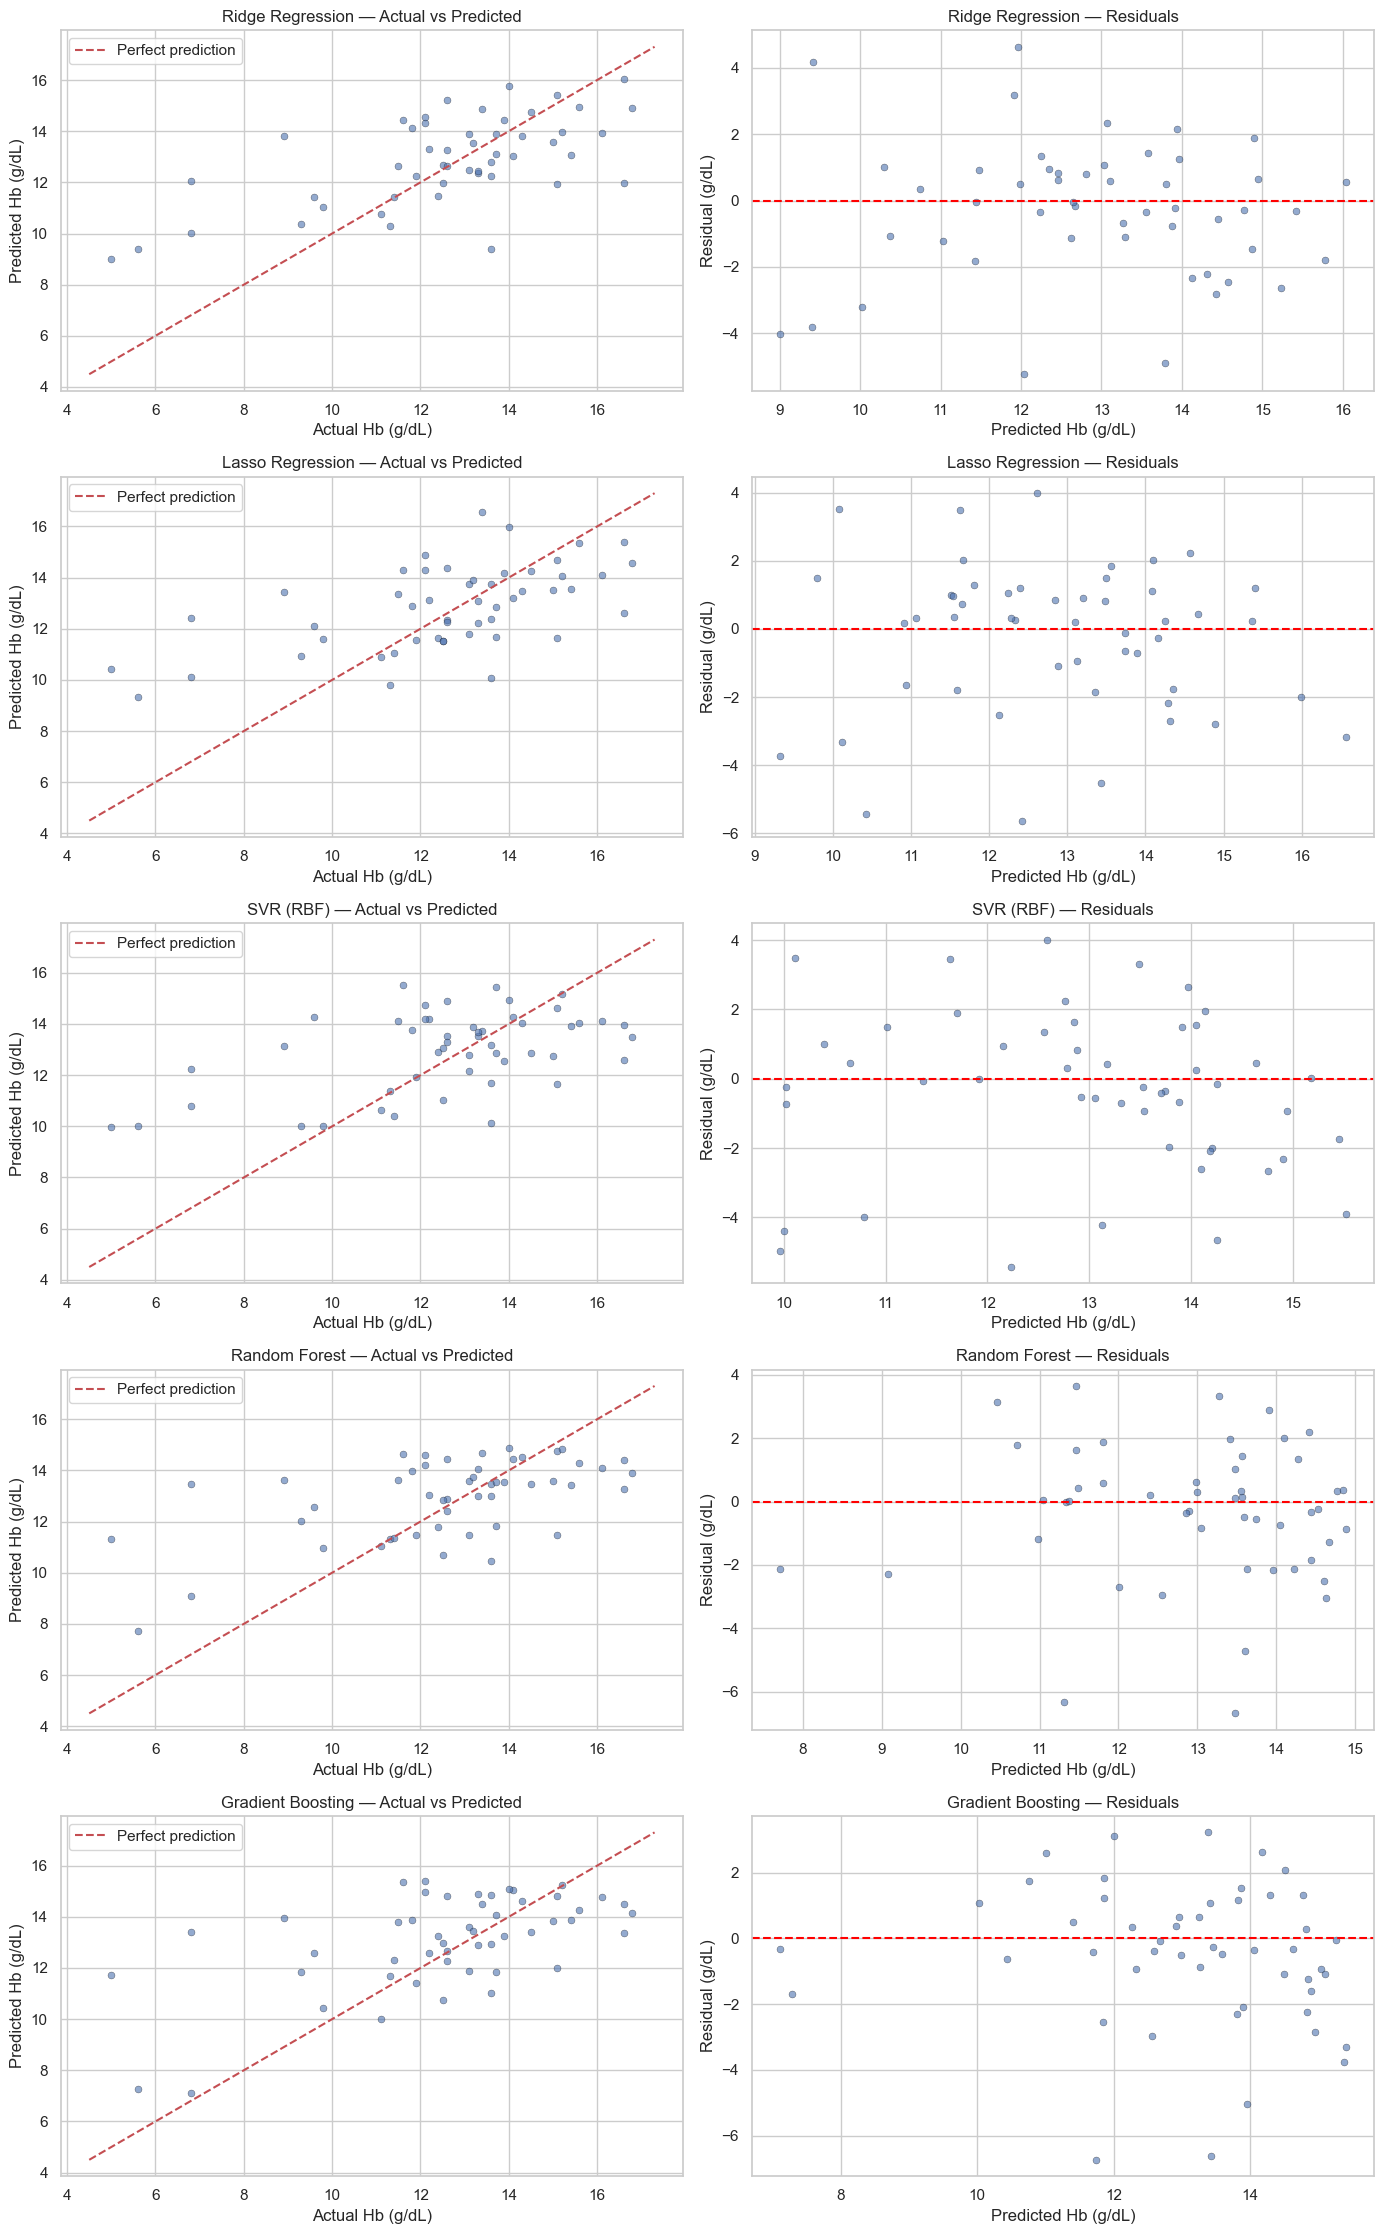

In [5]:
# Prediction scatter + residual plots for each model
n_models = len(trained_models)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 4.5 * n_models))

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_s)
    residuals = y_test - y_pred
    
    # Scatter: pred vs actual
    ax1 = axes[i][0]
    ax1.scatter(y_test, y_pred, alpha=0.6, s=25, edgecolors="black", linewidth=0.3)
    lims = [min(y_test.min(), y_pred.min()) - 0.5, max(y_test.max(), y_pred.max()) + 0.5]
    ax1.plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
    ax1.set_xlabel("Actual Hb (g/dL)")
    ax1.set_ylabel("Predicted Hb (g/dL)")
    ax1.set_title(f"{name} — Actual vs Predicted")
    ax1.legend()
    
    # Residuals
    ax2 = axes[i][1]
    ax2.scatter(y_pred, residuals, alpha=0.6, s=25, edgecolors="black", linewidth=0.3)
    ax2.axhline(y=0, color="red", linestyle="--", lw=1.5)
    ax2.set_xlabel("Predicted Hb (g/dL)")
    ax2.set_ylabel("Residual (g/dL)")
    ax2.set_title(f"{name} — Residuals")

plt.tight_layout()
plt.show()

## 5. Feature Importance (Gradient Boosting)

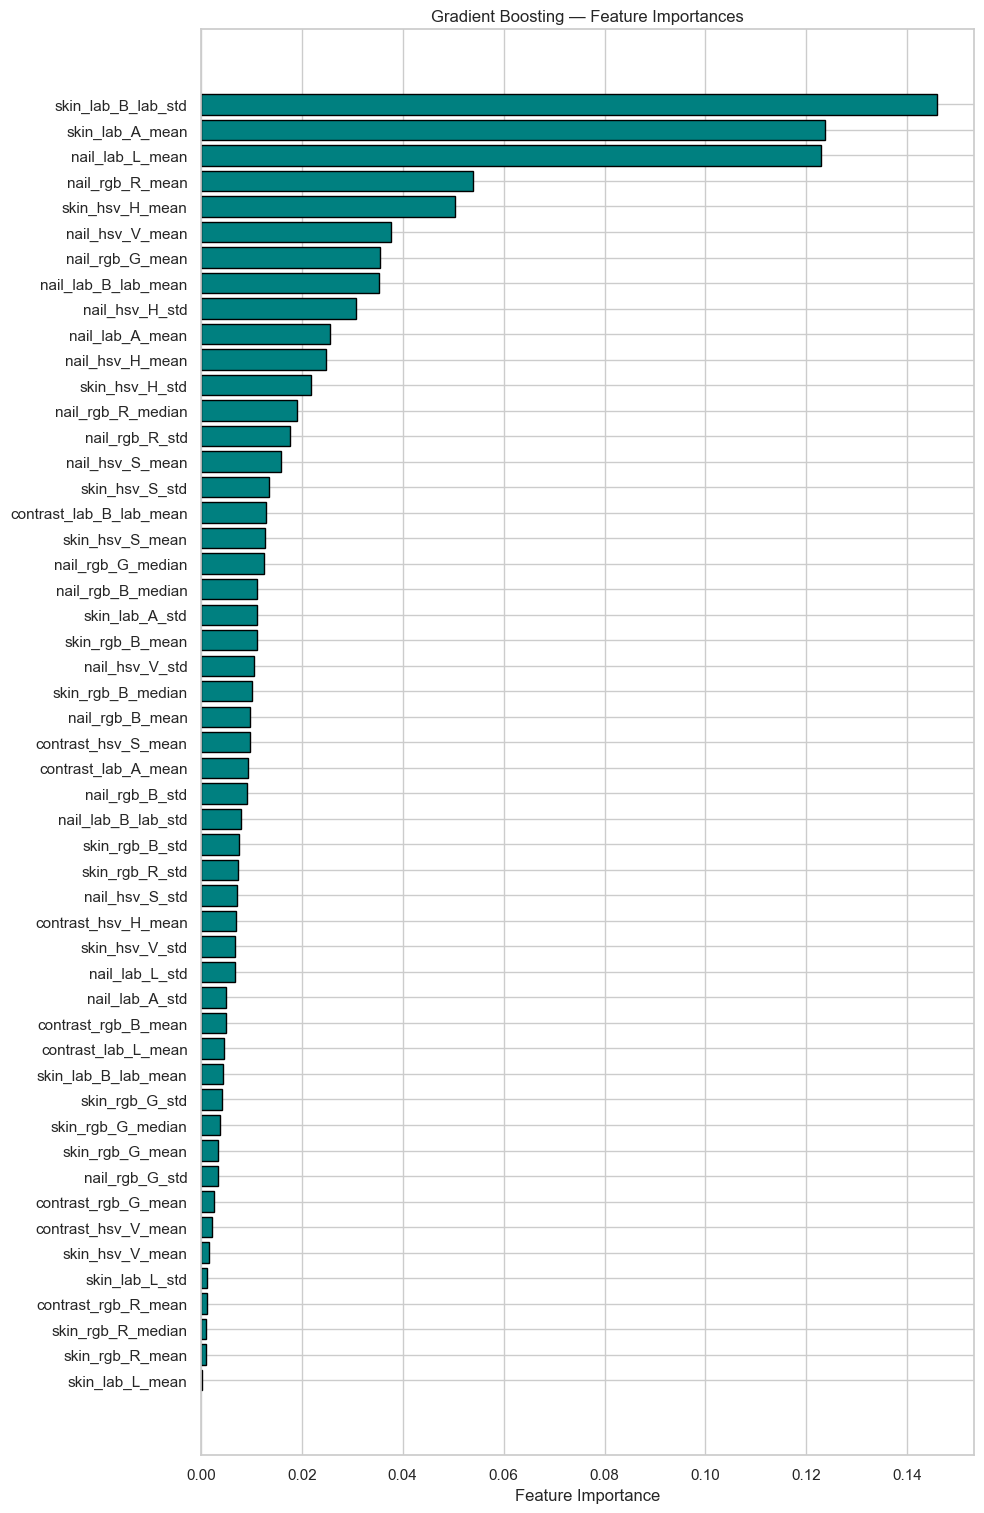

Top 10 features:
  skin_lab_B_lab_std                   importance = 0.1459
  skin_lab_A_mean                      importance = 0.1237
  nail_lab_L_mean                      importance = 0.1229
  nail_rgb_R_mean                      importance = 0.0539
  skin_hsv_H_mean                      importance = 0.0504
  nail_hsv_V_mean                      importance = 0.0378
  nail_rgb_G_mean                      importance = 0.0356
  nail_lab_B_lab_mean                  importance = 0.0353
  nail_hsv_H_std                       importance = 0.0307
  nail_lab_A_mean                      importance = 0.0255


In [6]:
# Feature importance from Gradient Boosting
gb_model = trained_models["Gradient Boosting"]
importances = gb_model.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, max(6, len(feature_cols) * 0.3)))
ax.barh(np.array(feature_cols)[sorted_idx], importances[sorted_idx], color="teal", edgecolor="black")
ax.set_xlabel("Feature Importance")
ax.set_title("Gradient Boosting — Feature Importances")
plt.tight_layout()
plt.show()

# Top 10
print("Top 10 features:")
for idx in sorted_idx[-10:][::-1]:
    print(f"  {feature_cols[idx]:35s}  importance = {importances[idx]:.4f}")

## 6. Summary & Next Steps

**Baseline Results:**
- Traditional ML models trained on hand-crafted color features (RGB, LAB, HSV means/stds from nail & skin ROIs, plus nail-vs-skin contrast features)
- Evaluated on a 80/20 train/test split with 5-fold cross-validation

**Targets for ViT model (to beat baselines):**
- MAE < 1.0 g/dL
- R² > 0.75
- Clinical relevance: within ±1.5 g/dL of lab-measured Hb

**Next Steps:**
1. Use these MAE / R² numbers as the floor to beat with the ViT model in `model/train.py`
2. Consider session-aware splits (group-by `MEASUREMENT_DATE`) to prevent data leakage
3. Explore data augmentation strategies for the deep learning pipeline
4. Investigate per-class performance — models likely struggle on severe anemia (few samples)